df_X: (442, 10)  df_y: (442,)
(353, 10) (89, 10) (353,) (89,)
Iteration   3000 : train Loss 2898.7568
Iteration   6000 : train Loss 2895.4994
Iteration   9000 : train Loss 2893.5289
Iteration  12000 : train Loss 2891.7130
Iteration  15000 : train Loss 2890.0307
Iteration  18000 : train Loss 2888.4714
Iteration  21000 : train Loss 2887.0257
Iteration  24000 : train Loss 2885.6852
Iteration  27000 : train Loss 2884.4420
Iteration  30000 : train Loss 2883.2891


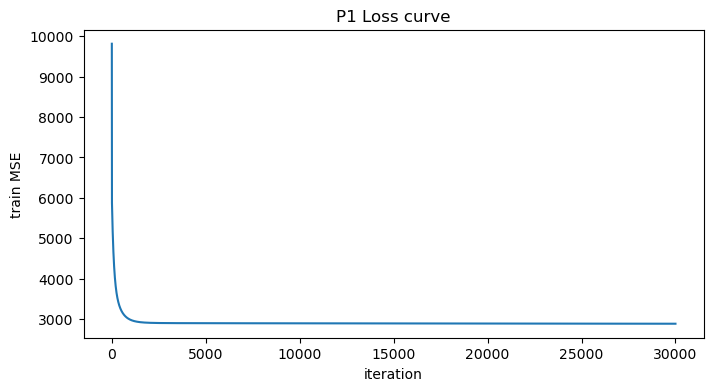

[P1] Test MSE : 2886.5863
[P1] 루브릭 통과 (MSE <= 3000)


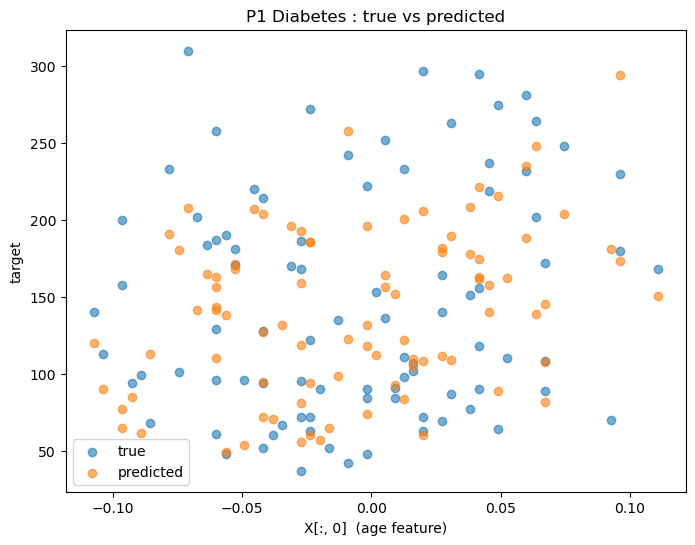

In [6]:
# ============================================================
# Project 1 : 손수 설계하는 선형회귀 - 당뇨병 수치 예측
# 목표: test MSE <= 3000
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

# (1) 데이터 가져오기
diabetes = load_diabetes()
df_X = diabetes.data      # (442, 10) 이미 정규화된 특성
df_y = diabetes.target    # 25 ~ 346
print("df_X:", df_X.shape, " df_y:", df_y.shape)

# (2) X 준비
X = np.array(df_X)

# (3) y 준비
y = np.array(df_y)

# (4) train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# (5) 모델 준비
np.random.seed(42)
W = np.random.rand(X.shape[1])   # 특성 10개 -> 가중치 10개
b = np.random.rand()

def model(X, W, b):
    return X.dot(W) + b          # 예측값 = XW + b

# (6) 손실함수 (MSE)
def loss(X, W, b, y):
    pred = model(X, W, b)
    return ((pred - y) ** 2).mean()

# (7) gradient
def gradient(X, W, b, y):
    N = len(y)
    error = model(X, W, b) - y
    dW = (2 / N) * X.T.dot(error)
    db = (2 / N) * error.sum()
    return dW, db

# (8) 학습률
LEARNING_RATE = 0.3   # 1.0은 발산, 0.3이 안정적

# (9) 학습
losses = []
n_iter = 30000
for i in range(1, n_iter + 1):
    dW, db = gradient(X_train, W, b, y_train)
    W -= LEARNING_RATE * dW
    b -= LEARNING_RATE * db
    L = loss(X_train, W, b, y_train)
    losses.append(L)
    if i % 3000 == 0:
        print(f"Iteration {i:>6} : train Loss {L:.4f}")

# 손실 곡선
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("iteration"); plt.ylabel("train MSE")
plt.title("P1 Loss curve"); plt.show()

# (10) test 성능
prediction = model(X_test, W, b)
mse = ((prediction - y_test) ** 2).mean()
print(f"[P1] Test MSE : {mse:.4f}")
assert mse <= 3000, "기준(3000) 미달 - learning rate / n_iter 조정 필요"
print("[P1] 루브릭 통과 (MSE <= 3000)")

# (11) 정답 vs 예측 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X_test[:, 0], y_test, alpha=0.6, label="true")
plt.scatter(X_test[:, 0], prediction, alpha=0.6, label="predicted")
plt.xlabel("X[:, 0]  (age feature)"); plt.ylabel("target")
plt.title("P1 Diabetes : true vs predicted")
plt.legend(); plt.show()

(10886, 12)


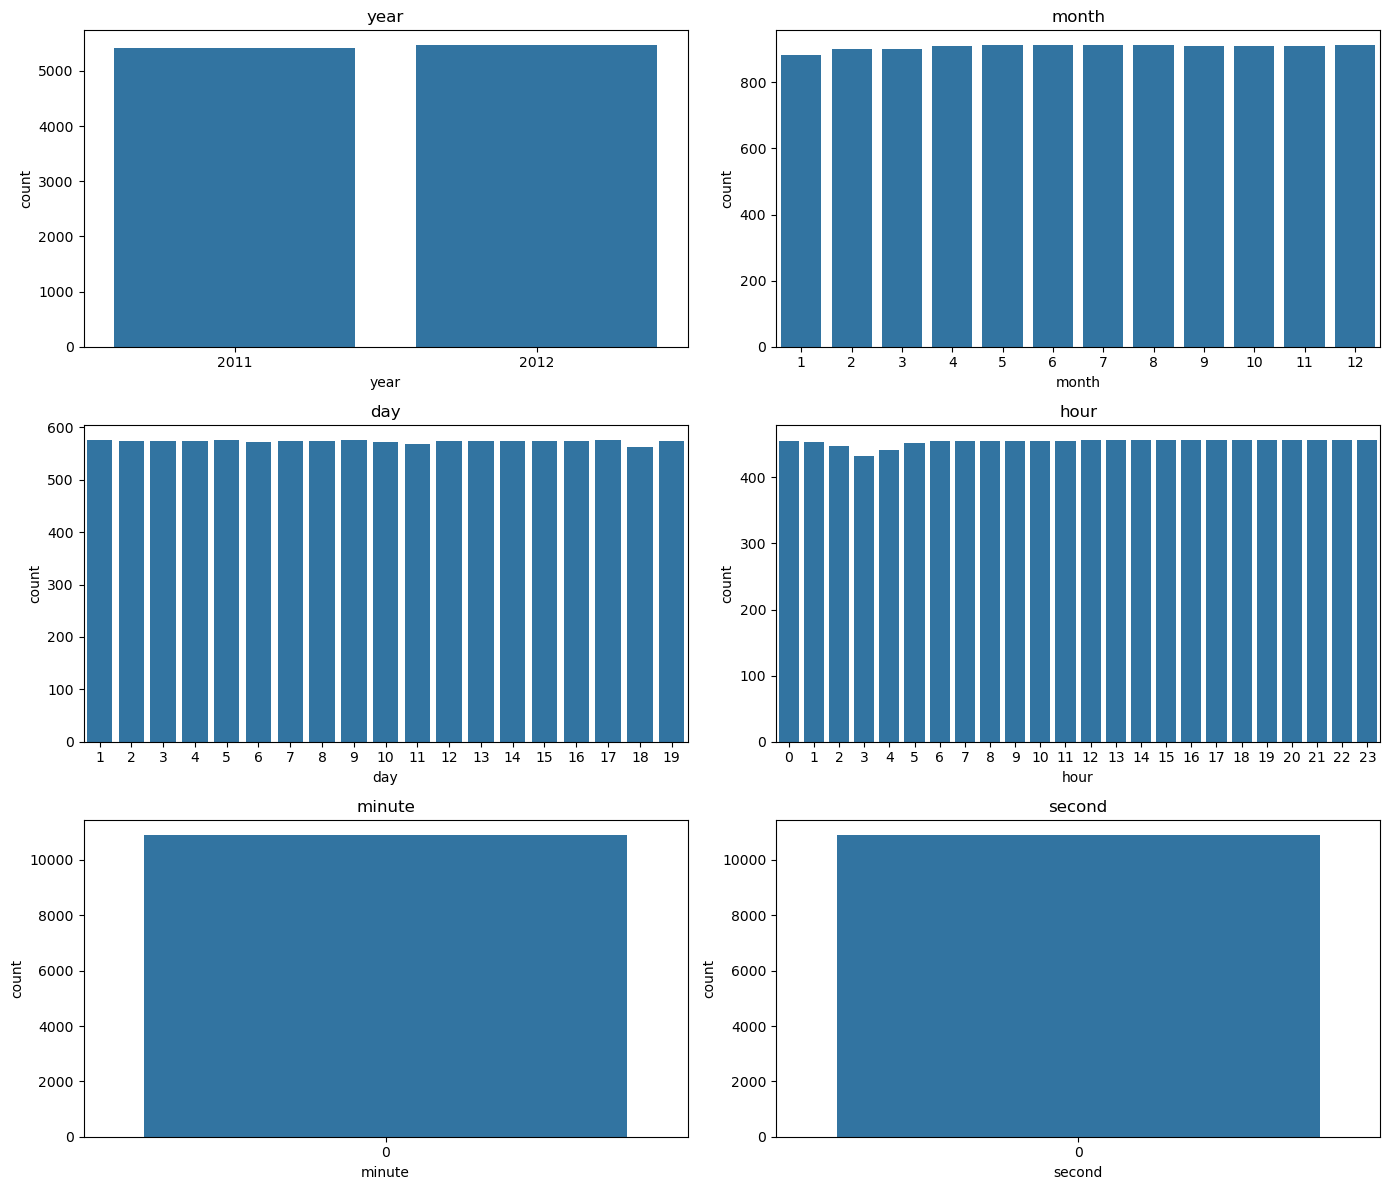

[P2] RMSE (숫자 그대로)        : 141.2281
[P2] RMSE (hour 원-핫)         : 101.8689
[P2] RMSE (hour+season+weather+month 원-핫) : 100.2696


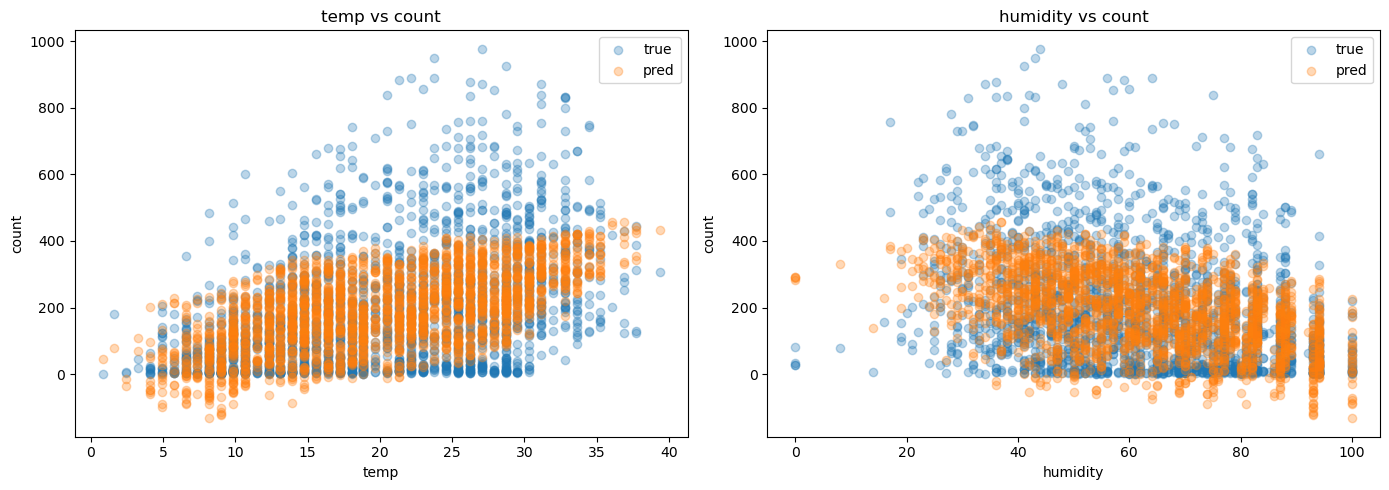

In [8]:
# ============================================================
# Project 2 : 자전거 대여량 예측 (sklearn LinearRegression)
# 목표: RMSE <= 150
# ============================================================
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# (1) 데이터 가져오기
csv_path = os.path.expanduser("~/data/data/bike-sharing-demand/train.csv")
train = pd.read_csv(csv_path)
print(train.shape)

# (2) datetime 변환 + 6개 컬럼
train["datetime"] = pd.to_datetime(train["datetime"])
train["year"]   = train["datetime"].dt.year
train["month"]  = train["datetime"].dt.month
train["day"]    = train["datetime"].dt.day
train["hour"]   = train["datetime"].dt.hour
train["minute"] = train["datetime"].dt.minute
train["second"] = train["datetime"].dt.second

# (3) 데이터 개수 시각화 (countplot x 6)
cols = ["year", "month", "day", "hour", "minute", "second"]
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
for ax, col in zip(axes.flatten(), cols):
    sns.countplot(x=col, data=train, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

y = train["count"]

# ------------------------------------------------------------
# (4~6) 버전 1 : 숫자 그대로 (baseline)
# ------------------------------------------------------------
feature_cols = ["year", "month", "day", "hour",
                "season", "holiday", "workingday", "weather",
                "temp", "atemp", "humidity", "windspeed"]
X = train[feature_cols]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
pred = lr_model.predict(X_test)
rmse_base = np.sqrt(((pred - y_test) ** 2).mean())
print(f"[P2] RMSE (숫자 그대로)        : {rmse_base:.4f}")

# ------------------------------------------------------------
# 버전 2 : hour만 원-핫
# ------------------------------------------------------------
onehot_cols = ["year", "month", "day",
               "season", "holiday", "workingday", "weather",
               "temp", "atemp", "humidity", "windspeed"]
X_oh = pd.concat([train[onehot_cols],
                  pd.get_dummies(train["hour"], prefix="hour")], axis=1)
Xtr, Xte, ytr, yte = train_test_split(X_oh, y, test_size=0.2, random_state=42)
m2 = LinearRegression().fit(Xtr, ytr)
p2 = m2.predict(Xte)
rmse_hour = np.sqrt(((p2 - yte) ** 2).mean())
print(f"[P2] RMSE (hour 원-핫)         : {rmse_hour:.4f}")

# ------------------------------------------------------------
# 버전 3 : hour + season + weather + month 원-핫
# ------------------------------------------------------------
num_cols = ["year", "day", "holiday", "workingday",
            "temp", "atemp", "humidity", "windspeed"]   # 숫자로 둘 컬럼
cat_cols = ["hour", "season", "weather", "month"]        # 원-핫 할 범주형

X_full = pd.concat(
    [train[num_cols]] +
    [pd.get_dummies(train[c], prefix=c) for c in cat_cols],
    axis=1
)
Xtr3, Xte3, ytr3, yte3 = train_test_split(X_full, y, test_size=0.2, random_state=42)
m3 = LinearRegression().fit(Xtr3, ytr3)
p3 = m3.predict(Xte3)
rmse_full = np.sqrt(((p3 - yte3) ** 2).mean())
print(f"[P2] RMSE (hour+season+weather+month 원-핫) : {rmse_full:.4f}")

# (7) temp, humidity vs count 시각화 (baseline 예측 기준)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_test["temp"], y_test, alpha=0.3, label="true")
axes[0].scatter(X_test["temp"], pred, alpha=0.3, label="pred")
axes[0].set_xlabel("temp"); axes[0].set_ylabel("count")
axes[0].set_title("temp vs count"); axes[0].legend()
axes[1].scatter(X_test["humidity"], y_test, alpha=0.3, label="true")
axes[1].scatter(X_test["humidity"], pred, alpha=0.3, label="pred")
axes[1].set_xlabel("humidity"); axes[1].set_ylabel("count")
axes[1].set_title("humidity vs count"); axes[1].legend()
plt.tight_layout(); plt.show()